# IF3270 Machine Learning | Praktikum 4
# Recurrent Neural Network
## Multi-Step Time Series Forecasting: Prediksi Kualitas Udara (PM2.5)

This notebook only serves as a template for Praktikum 4, **please refer to specification docs to do this assignment**. Please create a copy of this notebook to complete your work. You can edit or add more code blocks, markdown blocks, or new sections if needed.

Group Number: 53

Group Members:
- Albi Arrizkya Putra (10122062)
- Timothy Niels Ruslim (10123053)

## Import Libraries

In [ ]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, TensorDataset

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

# Import other libraries if needed
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, Dense, Dropout

Using device: cpu


## Import Dataset

In [ ]:
import gdown
url = "https://drive.google.com/uc?export=download&id=14VNEmrvtNMOeGA7DBhPEW0exm9cI9uQX"
output = 'dataset.zip'
gdown.download(url, output)

Downloading...
From: https://drive.google.com/uc?export=download&id=14VNEmrvtNMOeGA7DBhPEW0exm9cI9uQX
To: /content/dataset.zip
100%|██████████| 6.55k/6.55k [00:00<00:00, 6.43MB/s]


'dataset.zip'

In [ ]:
!unzip dataset.zipy

unzip:  cannot find or open dataset.zipy, dataset.zipy.zip or dataset.zipy.ZIP.


In [ ]:
df = pd.read_csv("train.csv")
df['tanggal'] = pd.to_datetime(df['tanggal'])
df.set_index('tanggal', inplace=True)
df

,Unnamed: 0,pm10,pm25,so2,co,o3,no2,max,critical,categori,location
tanggal,,,,,,,,,,,
2021-01-01,0,43,NaN,58,29,35,65,65,O3,SEDANG,DKI2
2021-01-02,1,58,NaN,86,38,64,80,86,PM25,SEDANG,DKI3
2021-01-03,2,64,NaN,93,25,62,86,93,PM25,SEDANG,DKI3
2021-01-04,3,50,NaN,67,24,31,77,77,O3,SEDANG,DKI2
2021-01-05,4,59,NaN,89,24,35,77,89,PM25,SEDANG,DKI3
...,...,...,...,...,...,...,...,...,...,...,...
2021-09-08,250,64,106.0,52,16,29,34,106,PM25,TIDAK SEHAT,DKI4
2021-09-09,251,68,88.0,54,12,35,31,88,PM25,SEDANG,DKI2
2021-09-10,252,58,80.0,53,10,39,32,80,PM25,SEDANG,DKI4


---
# 1. Exploratory Data Analysis (EDA)

*Exploratory Data Analysis* (EDA) adalah langkah krusial dalam proses analisis data yang melibatkan pemeriksaan dan visualisasi dataset untuk mengungkap pola, tren, anomali, dan *insight*.

### 1.1 [Wajib] Inspeksi Awal

Tampilkan `.head()`, `.info()`, dan `.describe()` untuk gambaran umum dataset.

In [ ]:
# Write your code here
display(df.head(5))

print("\nInfo Dataset:")
df.info()

print("\nStatistika Deskriptif:")
display(df.describe())

,Unnamed: 0,pm10,pm25,so2,co,o3,no2,max,critical,categori,location
tanggal,,,,,,,,,,,
2021-01-01,0,43,NaN,58,29,35,65,65,O3,SEDANG,DKI2
2021-01-02,1,58,NaN,86,38,64,80,86,PM25,SEDANG,DKI3
2021-01-03,2,64,NaN,93,25,62,86,93,PM25,SEDANG,DKI3
2021-01-04,3,50,NaN,67,24,31,77,77,O3,SEDANG,DKI2
2021-01-05,4,59,NaN,89,24,35,77,89,PM25,SEDANG,DKI3



Info Dataset:
<class 'pandas.DataFrame'>
DatetimeIndex: 255 entries, 2021-01-01 to 2021-09-12
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  255 non-null    int64  
 1   pm10        255 non-null    int64  
 2   pm25        224 non-null    float64
 3   so2         255 non-null    int64  
 4   co          255 non-null    int64  
 5   o3          255 non-null    int64  
 6   no2         255 non-null    int64  
 7   max         255 non-null    int64  
 8   critical    255 non-null    str    
 9   categori    255 non-null    str    
 10  location    255 non-null    str    
dtypes: float64(1), int64(7), str(3)
memory usage: 27.9 KB

Statistika Deskriptif:


,Unnamed: 0,pm10,pm25,so2,co,o3,no2,max
count,255.000000,255.000000,224.000000,255.000000,255.000000,255.000000,255.000000,255.000000
mean,127.000000,61.811765,97.941964,52.454902,16.019608,50.011765,35.270588,96.062745
std,73.756356,14.191459,24.638393,11.654344,5.925024,13.072325,17.557591,24.767342
min,0.000000,24.000000,44.000000,37.000000,8.000000,20.000000,13.000000,51.000000
25%,63.500000,55.000000,81.750000,45.000000,12.000000,41.000000,24.000000,78.000000
50%,127.000000,63.000000,99.000000,52.000000,15.000000,50.000000,31.000000,94.000000
75%,190.500000,70.000000,112.250000,54.500000,19.000000,57.500000,40.000000,110.000000
max,254.000000,95.000000,174.000000,126.000000,47.000000,151.000000,134.000000,174.000000


*Insight:*

Dataset terdiri dari data harian dari 1 Januari 2021 sampai dengan 12 September 2021 dengan total 255 baris. Dataset terdiri dari 11 kolom, di antranya fitur numerik polutan (`pm10`, `pm25`, `so2`, `co`, `o3`, `no2`), nilai `max`, serta fitur kategorikal (`critical`, `categori`, `location`). Rata-rata konsentrasi `pm25` berada di angka $97.941964$ dengan standar deviasi $24.638393$. Berdasarkan info dataset, terdapat $31$ *missing values* secara eksplisit pada kolom `pm25` sebab hanya ada $224$ baris non-null dari total $255$ baris.

### 1.2 [Wajib] Visualisasi Time Series

Plot setiap variabel numerik (pm10, pm25, so2, co, o3, no2, max) terhadap waktu. Amati dan komentari tren serta pola musiman yang terlihat.

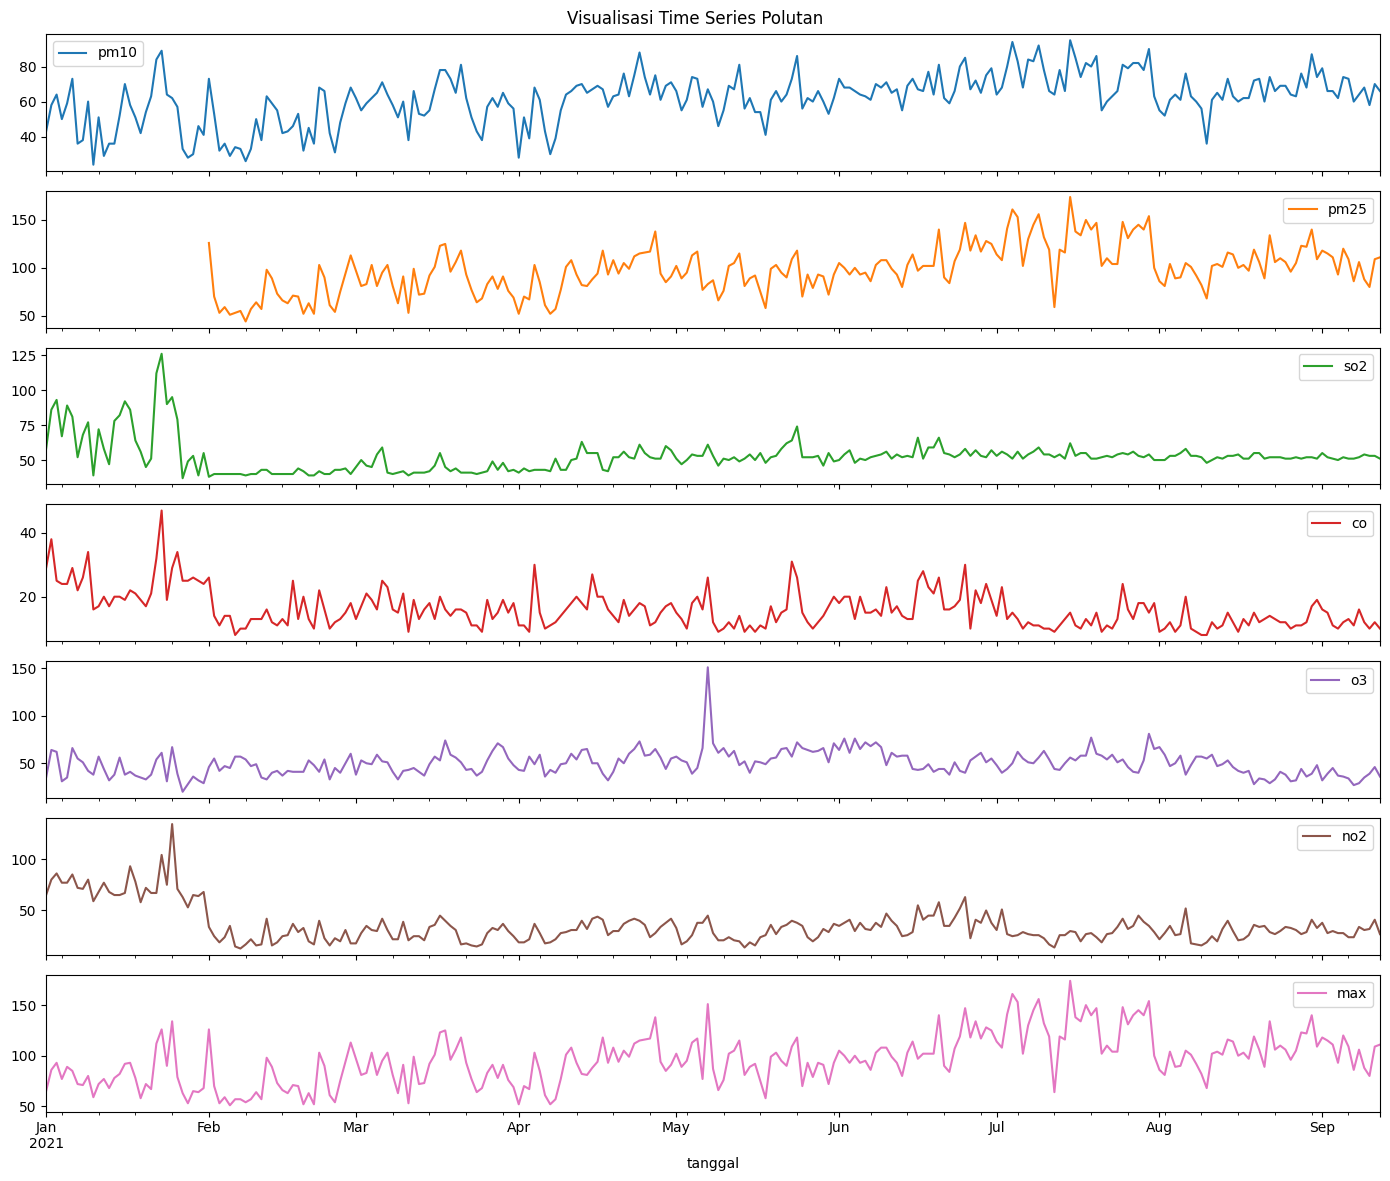

In [ ]:
# Write your code here
num_cols = ['pm10', 'pm25', 'so2', 'co', 'o3', 'no2', 'max']

df[num_cols].plot(subplots=True, figsize=(14, 12), title="Visualisasi Time Series Polutan")
plt.tight_layout()
plt.show()

*Insight:*

- Polutan `pm25` dan `pm10` menunjukkan pola fluktuasi yang sangat mirip satu sama lain, menunjukkan berasal dari sumber atau siklus sirkulasi udara yang serupa. Selain itu, fluktuasi terjadi hampir pada semua polutan.

- Terdapat pola penurunan yang serupa pada polutan `so2`, `co`, dan `no2` di akhir Januari hingga awal Februari. Pada bulan Januari, ketiganya memiliki konsentrasi tinggi dengan fluktuasi tajam, tetapi setelah Februari nilainya anjlok dan menjadi jauh lebih rendah serta stabil.

- Terdapat lonjakan tajam secara tidak teratur, seperti pada polutan `o3` dan `so2` di pertengahan tahun.

- Kolom `max` merupakan kurva amplop yang menentukan konsentrasi dominan tertinggi di antara semua polutan setiap harinya.

### 1.3 [Wajib] Analisis Distribusi

Visualisasikan distribusi tiap fitur (histogram/boxplot). Identifikasi skewness dan kehadiran outlier.

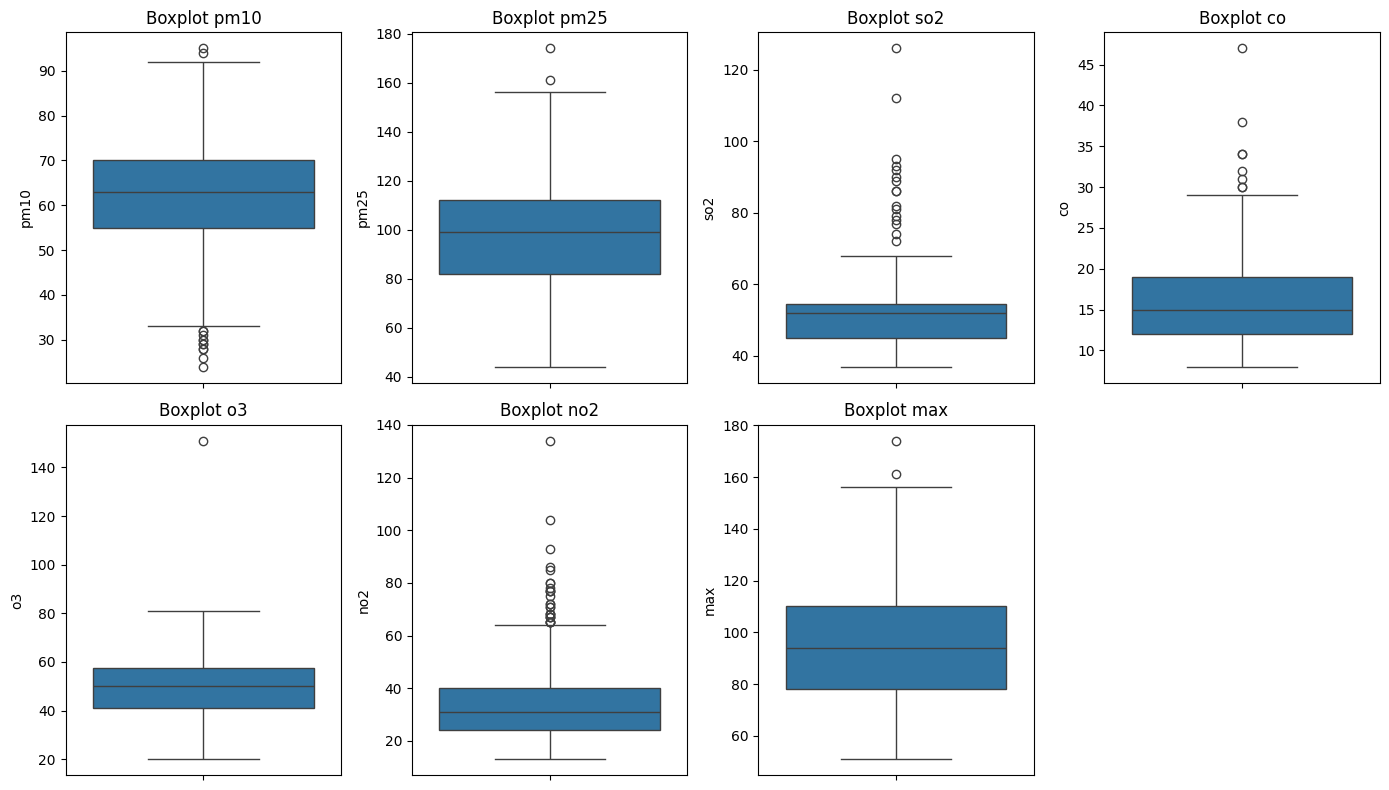

In [ ]:
# Write your code here
plt.figure(figsize=(14, 8))
for i, col in enumerate(num_cols, 1):
  plt.subplot(2, 4, i)
  sns.boxplot(y=df[col])
  plt.title(f"Boxplot {col}")
plt.tight_layout()
plt.show()

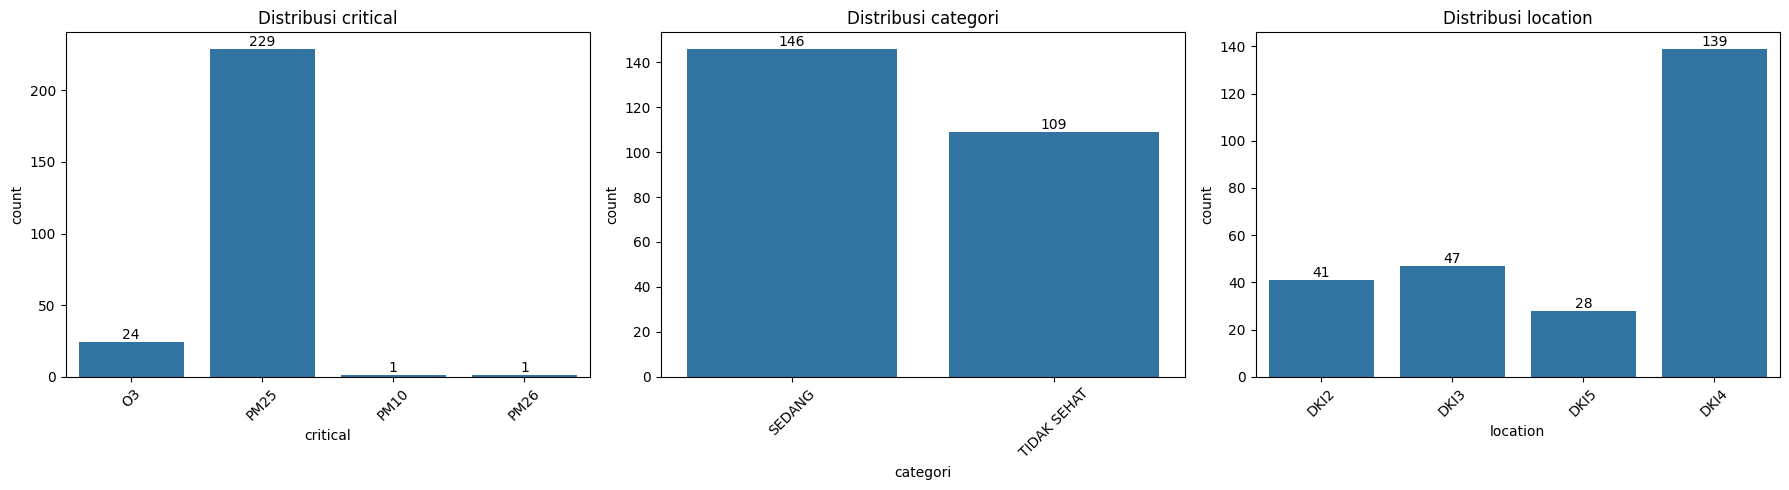

In [ ]:
cat_cols = ['critical', 'categori', 'location']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(cat_cols):
  sns.countplot(data=df, x=col, ax=axes[i])
  axes[i].set_title(f'Distribusi {col}')
  axes[i].tick_params(axis='x', rotation=45)

  for p in axes[i].patches:
    axes[i].annotate(f'{int(p.get_height())}',
                      (p.get_x() + p.get_width() / 2., p.get_height()),
                      ha='center', va='center', xytext=(0, 5),
                      textcoords='offset points')

plt.tight_layout()
plt.show()

*Insight:*

Fitur Numerik:
- Polutan seperti `so2`, `co`, `o3`, dan `no2` berdistribusi menceng kanan (*right-skewed*) dengan ekor yang panjang di nilai atas. Sementara itu, distribusi `pm25` relatif lebih simetris dibandingkan polutan lainnya.

- Berdasarkan boxplot, keberadaan nilai *outlier* terlihat jelas terutama pada polutan `so2`, `no`, `o3`, dan `no2`. Hal ini wajar dalam data kualitas udara karena faktor eksternal mendadak.



Fitur Kategorikal:
- Fitur `critical` distribusi sangat timpang. PM25 mendominasi sebagai polutan utama penyumbang kualitas udara yang memburuk sebesar $229$ observasi.

- Fitur `categori` didominasi oleh kategori "SEDANG" sebanyak $146$ hari dan "TIDAK SEHAT" sebanyak $109$ hari. Tidak tercatat adanya hari dengan kualitas udara "BAIK" atau kategori yang lebih buruk seperti "SANGAT TIDAK SEHAT".

- Fitur `location` berdistribusi tidak seimbang. Sebagian besar data yaitu $139$ observasi diambil dari stasiun DKI4. Sementara itu, data dari DKI2, DKI3, dan DKI5 jumlahnya jauh lebih sedikit, serta stasiun DKI1 sama sekali tidak ada di dalam dataset.

### 1.4 [Wajib] Analisis Missing Value

Kuantifikasi jumlah dan persentase missing value per kolom. Visualisasikan pola missing (apakah terklaster pada periode tertentu?).

      Jumlah Missing  Persentase (%)
pm25              31       12.156863


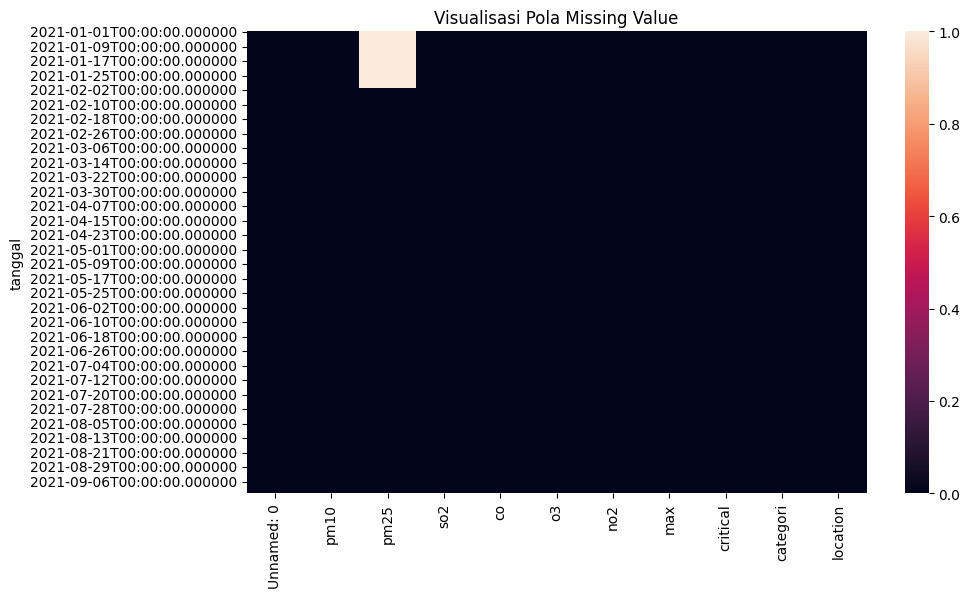

In [ ]:
# Write your code here
missing_counts = df.isnull().sum()
missing_percent = (missing_counts / len(df)) * 100
missing_df = pd.DataFrame({'Jumlah Missing': missing_counts, 'Persentase (%)': missing_percent})
print(missing_df[missing_df['Jumlah Missing'] > 0])

plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull())
plt.title("Visualisasi Pola Missing Value")
plt.show()

*Insight:*

- Terdapat $31$ *missing values* pada fitur target `pm25` yang mewakili sekitar $12.16\%$ dari total data.

- Berdasarkan visualisasi pola *missing values*, data yang hilang tidak terjadi secara acak. Data yang *missing values* terklaster pada bulan pertama pencatatan, yaitu pada Januari 2021. Sebelum kita melakukan *forecasting*, kita perlu mengisi nilai ini dengan teknik yang tepat karena akan mempengaruhi hasil *forecasting* ke depannya.

### 1.5 [Wajib] Analisis Korelasi

Buat heatmap korelasi antar fitur numerik. Interpretasikan kekuatan dan arah hubungan antar polutan.

In [ ]:
!pip install dython

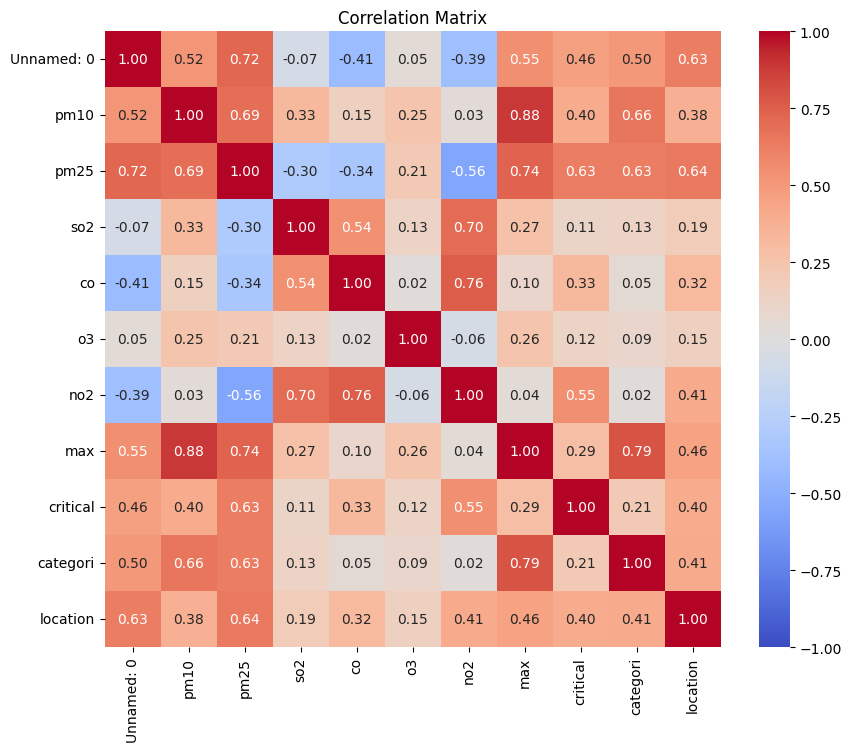

In [ ]:
# Write your code here
from dython.nominal import associations

df_dython = df.copy()

for col in df_dython.select_dtypes(include=['string', 'object', 'category']).columns:
    df_dython[col] = df_dython[col].astype('object')

dython_result = associations(
  df_dython,
  figsize=(10, 8),
  title="Correlation Matrix",
  cmap='coolwarm',
)

plt.show()

*Insight:*

- Terdapat korelasi positif yang cukup kuat sebesar $0.69$ antara polutan `pm10` dan `pm25`. Hal ini disebabkan kedua polutan berasal dari sumber yang sama.

- Terdapat hubungan positif kuat juga antara polutan `no2` dengan `co` sebesar $0.76$ serta polutan `no2` dengan `so2` sebesar $0.70$. Hal ini menunjukkan emisi gas kendaraan atau industri yang berjalan bersamaan.

- Kolom `max` memiliki korelasi positif yang sangat kuat dengan `pm10` sebesar $0.88$ dan `pm25` sebesar $0.74$. Hal ini menunjukkan bahwa kelompok polutan tersebut merupakan penyumbang paling dominan dan penentu utama status kualitas udara harian dibandingkan gas polutan lainnya.

- Terdapat korelasi negatif yang moderat antara `no2` dan `pm25` sebesar $-0.56$, menunjukkan kecenderungan bahwa saat konsentrasi partikel halus meningkat, gas nitrogen dioksida cenderung menurun, dan sebaliknya.

### 1.6 [Wajib] Seasonal Decomposition

Lakukan dekomposisi deret waktu (trend, seasonal, residual) menggunakan metode additive atau multiplicative. Diskusikan temuan.

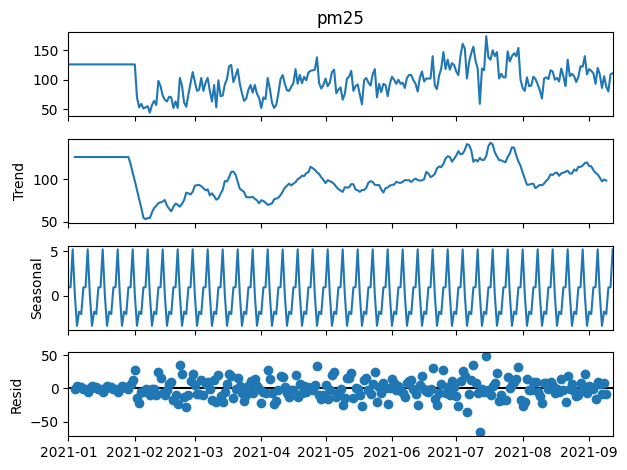

In [ ]:
# Write your code here
from statsmodels.tsa.seasonal import seasonal_decompose
temp_series = df['pm25'].bfill()
result = seasonal_decompose(temp_series, model='additive', period=7)
result.plot()
plt.show()


*Insight:*


- Pola Makro (Trend): Komponen tren tidak hanya sekadar fluktuatif, tetapi menunjukkan juga pergerakan makro yang jelas. Tren konsentrasi `pm25` relatif rendah di awal tahun (Februari - April), kemudian mengalami tren peningkatan yang stabil sejak Mei sampai mencapai puncaknya di bulan Juli.

- Pola Mikro (Seasonal): Terdapat pola musiman jangka pendek seperti siklus mingguan. Namun, amplitudo dari siklus ini sangat kecil (hanya berkisar di angka -4 hingga +5). Hal ini menunjukkan bahwa meskipun terdapat perbedaan rutin harian, sehingga dampaknya tidak terlalu signifikan dibandingkan faktor tren makro.

- Faktor Residual: Komponen residual memiliki sebaran yang cukup besar, yakni berkisar antara $-30$ hingga $+50$, menunjukkan bahwa tingkat polusi `pm25` sangat rentan terhadap kondisi cuaca harian yang tidak terprediksi.

---
# 2. Data Cleaning and Preprocessing

Tahap ini mempersiapkan data mentah menjadi format yang dapat digunakan oleh model deep learning. Untuk data deret waktu multivariat dengan multi-step forecasting, terdapat beberapa langkah kritis yang harus dilakukan secara berurutan.

### 2.1 [Wajib] Penanganan Missing Value

Pilih strategi penanganan missing value yang sesuai (interpolasi linear/time-based, forward fill, atau drop). Berikan justifikasi atas pilihan yang dibuat.

In [ ]:
# Write your code here
# Handle missing values pada kolom pm25
df['pm25'] = df['pm25'].interpolate(method='time').bfill()
print(f"Sisa missing value: {df['pm25'].isna().sum()}")

Sisa missing value: 0


*Justification:* Data *time series* membutuhkan data yang berurutan secara kronologis. Interpolasi dilakukan untuk menjaga tren garis, lalu *backward-fill* `bfill()` secara spesifik menangani *missing values* di waktu awal (data bulan Januari) yang tidak bisa dilakukan interpolasi. Hal ini lebih baik daripada `dropna()` agar tidak membuang sampel waktu sama sekali.

### 2.2 [Wajib] Penanganan Outlier

Identifikasi dan tangani outlier ekstrem (misalnya menggunakan IQR atau clipping). Pertimbangkan apakah outlier pada data lingkungan memiliki makna fisis sebelum dihapus.

In [ ]:
# Write your code here
# Handle outliers
num_cols = ['pm10', 'pm25', 'so2', 'co', 'o3', 'no2', 'max']

for col in num_cols:
  upper_limit = df[col].quantile(0.99)
  df[col] = df[col].clip(upper=upper_limit)

*Justification:* Metode clipping menahan lonjakan nilai *outliers* agar tidak terlalu mengganggu penghitungan loss dengan tetap mempertahankan representasi historis bahwa di waktu tersebut terjadi lonjakan kualitas udara yang memburuk, atau dengan kata lain, informasinya tidak dibuang.

### 2.3 [Wajib] Feature Selection

Pilih fitur input yang relevan untuk prediksi pm25. Dukung keputusan dengan hasil korelasi dari tahap EDA.

In [ ]:
# Write your code here
# Select relevant features

cat_mapping = {
    'BAIK': 0,
    'SEDANG': 1,
    'TIDAK SEHAT': 2,
    'SANGAT TIDAK SEHAT': 3,
    'BERBAHAYA': 4
}
df['categori_encoded'] = df['categori'].map(cat_mapping).fillna(1)
df = pd.get_dummies(df, columns=['critical', 'location'], drop_first=False)

for col in df.columns:
  if df[col].dtype == bool:
    df[col] = df[col].astype(int)

df = df.drop(columns=['categori', 'Unnamed: 0'], errors='ignore')

cols_to_drop = ['Unnamed: 0', 'critical', 'categori']
cols_to_drop = [c for c in cols_to_drop if c in df.columns]
df = df.drop(columns=cols_to_drop)

print("Fitur akhir:", df.columns.tolist())

Fitur akhir: ['pm10', 'pm25', 'so2', 'co', 'o3', 'no2', 'max', 'categori_encoded', 'critical_O3', 'critical_PM10', 'critical_PM25', 'critical_PM26', 'location_DKI2', 'location_DKI3', 'location_DKI4', 'location_DKI5']


*Justification:* Fitur kategorikal tetap dipertahankan sebab fitur ini memiliki informasi yang penting untuk prediksi `pm25`. Selanjutnya perlu dilakukan encoding. Fitur `categori` mempunyai tingkatan (Baik < Sedang < Tidak Sehat) sehingga digunakan Ordinal Encoding. Fitur kategorikal lainnya tidak mempunyai tingkatan sehingga cukup dilakukan One-Hot Encoding.

### 2.5 [Wajib] Train/Val/Test Split (Kronologis)

Lakukan pemisahan dataset secara kronologis (time-aware split), **BUKAN acak**. Gunakan pembagian yang wajar, misalnya 70% train, 15% validation, 15% test.

In [ ]:
# Write your code here
# Chronological split
n = len(df)
train_set = df.iloc[0:int(n*0.8)].copy()
val_set = df.iloc[int(n*0.8):].copy()
print(f"Banyak data: {n}")
print(f"Banyak data train: {len(train_set)}, data validation: {len(val_set)}")

Banyak data: 255
Banyak data train: 204, data validation: 51


In [ ]:
# Write your code here
# Fit scaler on training data ONLY, then transform val/test
scaler = StandardScaler()

train_scaled = scaler.fit_transform(train_set)
val_scaled = scaler.transform(val_set)

target_idx = df.columns.get_loc('pm25')
print(f"Index target (pm25): {target_idx}")

Index target (pm25): 1


*Justification:* Pemisahan *time-aware split* wajib dilakukan agar kita mensimulasikan skenario dunia nyata, yaitu memprediksi masa depan berdasarkan data historis masa lalu.

### 2.4 [Wajib] Scaling / Normalisasi

Lakukan normalisasi/standarisasi pada fitur numerik. Gunakan MinMaxScaler atau StandardScaler.

**PERHATIAN: scaler harus di-fit HANYA pada data training, kemudian ditransformasi ke validation dan test set.**

In [ ]:
# Write your code here
# Fit scaler on training data ONLY, then transform val/test
scaler = StandardScaler()

train_scaled = scaler.fit_transform(train_set)
val_scaled = scaler.transform(val_set)

target_idx = df.columns.get_loc('pm25')
print(f"Index target (pm25): {target_idx}")

Index target (pm25): 1


*Justification:* Dipilih `StandardScaler` karena scaler ini lebih unggul untuk generalisasi dan sensitivitas terhadap outlier lebih rendah. Scaler hanya di-*fit* pada data *training* untuk mencegah data *leakage*.

### 2.6 [Wajib] Sliding Window Multi-Step

Implementasikan sliding window untuk menghasilkan pasangan (X, Y) di mana:
- X: sekuens L timestep dari fitur input, shape (N, L, F)
- Y: nilai pm25 untuk H timestep berikutnya, shape (N, H)

Justifikasi nilai L dan H yang dipilih.

In [ ]:
# Write your code here
def create_sliding_window(data, target_col_idx, L, H):
  X, Y = [], []
  for i in range(len(data)-L-H+1):
    X.append(data[i:i+L, :])
    Y.append(data[i+L:i+L+H, target_col_idx])
  return np.array(X), np.array(Y)

In [ ]:
# Parameter eksplorasi:
L_window = 14
H_step = 7

X_train, Y_train = create_sliding_window(train_scaled, target_idx, L_window, H_step)
X_val, Y_val = create_sliding_window(val_scaled, target_idx, L_window, H_step)

print(f"Shape X_train: {X_train.shape} (Samples, Timesteps L, Features)")
print(f"Shape Y_train: {Y_train.shape} (Samples, Timesteps H)")

Shape X_train: (184, 14, 16) (Samples, Timesteps L, Features)
Shape Y_train: (184, 7) (Samples, Timesteps H)


*Justification for L and H:*

- Dipilih $L=14$. Berdasarkan hasil dekomposisi yang memiliki residual noise tinggi pada bagian 1.6, melihat data hanya sekian hari ke belakang tidaklah cukup. Dengan menggunakan observasi historis sepanjang $14$ hari akan memberikan model kesempatan yang lebih baik dalam menangkap tren fluktuasi mingguan polutan.

- Dipilih $H=7$. Digunakan untuk skenario peringatan dini kualitas udara selama $1$ minggu ke depan.


### Helper: PyTorch Dataset & DataLoader

In [ ]:
# Define PyTorch Dataset and create DataLoaders
# Write your code here

class AirQualityDataset(Dataset):
  def __init__(self, X, Y):
    self.X = torch.tensor(X, dtype=torch.float32)
    self.Y = torch.tensor(Y, dtype=torch.float32)

  def __len__(self):
    return len(self.X)

  def __getitem__(self, idx):
    return self.X[idx], self.Y[idx]

train_dataset = AirQualityDataset(X_train, Y_train)
val_dataset = AirQualityDataset(X_val, Y_val)

BATCH_SIZE = 16

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

for X_batch, Y_batch in train_loader:
    print(f"Bentuk X batch: {X_batch.shape}")
    print(f"Bentuk Y batch: {Y_batch.shape}")
    break

Bentuk X batch: torch.Size([16, 14, 16])
Bentuk Y batch: torch.Size([16, 7])


---
# 3. Modeling and Validation

Pada praktikum ini, Anda diminta mengimplementasikan dan membandingkan dua model:
1. **Vanilla RNN** — dibangun menggunakan PyTorch atau TensorFlow/Keras.
2. **LSTM** — dengan konfigurasi yang sebanding dengan RNN.

**Strategi Multi-Step Forecasting:** Pilih salah satu strategi dan berikan justifikasi:
- **Direct Multi-Output:** Model menghasilkan seluruh H nilai output sekaligus.
- **Recursive (One-step-ahead):** Model memprediksi 1 langkah, lalu output dimasukkan kembali.

**Strategi yang dipilih:** *Direct Multi-Output*. Justifikasi: Pada strategi ini, model memiliki node *output* sebanyak $H$ *timestep* yang diprediksi secara bersamaan. Strategi ini dapat menghindari akumulasi error yang biasa terjadi pada strategi *Recursive*. Pada *Recursive*, prediksi yang buruk di hari pertama akan merusak prediksi di hari kedua, ketiga, dan seterusnya karena dimasukkan kembali sebagai input. Pada *Direct Multi-Output* lebih stabil dan proses *training*-nya jauh lebih cepat.

### Helper: Training and Evaluation Functions

In [ ]:
# Define training loop, evaluation function, early stopping, and plotting utilities
# Write your code here

def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs, patience=10):
  train_losses = []
  val_losses = []

  best_val_loss = float('inf')
  epochs_no_improve = 0
  best_model_state = None

  for epoch in range(num_epochs):
    model.train()
    running_train_loss = 0.0

    for inputs, targets in train_loader:
      optimizer.zero_grad()

      outputs = model(inputs)
      loss = criterion(outputs, targets)

      loss.backward()
      optimizer.step()

      running_train_loss += loss.item() * inputs.size(0)

    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)

    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
      for inputs, targets in val_loader:
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        running_val_loss += loss.item() * inputs.size(0)

    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    val_losses.append(epoch_val_loss)

    print(f'Epoch {epoch+1}/{num_epochs} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f}')

    if epoch_val_loss < best_val_loss:
      best_val_loss = epoch_val_loss
      epochs_no_improve = 0
      best_model_state = model.state_dict()
    else:
      epochs_no_improve += 1
      if epochs_no_improve >= patience:
        print(f'Early stopping pada epoch {epoch+1}')
        break

  model.load_state_dict(best_model_state)
  return train_losses, val_losses

def evaluate_model(model, data_loader):
  model.eval()
  all_preds = []
  all_targets = []

  with torch.no_grad():
    for inputs, targets in data_loader:
      outputs = model(inputs)
      all_preds.append(outputs.numpy())
      all_targets.append(targets.numpy())

  all_preds = np.concatenate(all_preds, axis=0)
  all_targets = np.concatenate(all_targets, axis=0)
  return all_preds, all_targets

## 3.1 Model Vanilla RNN

Implementasikan Vanilla RNN menggunakan PyTorch. Gunakan minimal 1 layer rekuren. Sertakan justifikasi atas konfigurasi yang dipilih (jumlah hidden units, jumlah layer, dropout, dsb.).

In [ ]:
# Define Vanilla RNN architecture
# Write your code here
NUM_FEATURES = X_train.shape[2]
SEQ_LENGTH = 14
FORECAST_LENGTH = 7

class VanillaRNN(nn.Module):
  def __init__(self, input_size, hidden_size, num_layers, output_size, dropout=0.2):
    super(VanillaRNN, self).__init__()
    self.hidden_size = hidden_size
    self.num_layers = num_layers
    self.rnn = nn.RNN(input_size, hidden_size, num_layers,
                      batch_first=True, dropout=dropout if num_layers > 1 else 0)
    self.dropout = nn.Dropout(dropout)
    self.fc = nn.Linear(hidden_size, output_size)

  def forward(self, x):
    out, hidden = self.rnn(x)
    last_out = out[:, -1, :]
    last_out = self.dropout(last_out)
    predictions = self.fc(last_out)
    return predictions

class RMSELoss(nn.Module):
  def __init__(self):
    super().__init__()
    self.mse = nn.MSELoss()

  def forward(self,yhat,y):
    return torch.sqrt(self.mse(yhat,y))

In [ ]:
# Print RNN architecture and total parameter count
# Write your code here
rnn_model = VanillaRNN(
    input_size=NUM_FEATURES,
    hidden_size=64,
    num_layers=1,
    output_size=FORECAST_LENGTH,
    dropout=0.2
    )
print(rnn_model)

# Total parameter count
total_params = sum(p.numel() for p in rnn_model.parameters() if p.requires_grad)
print(f"Total parameter count: {total_params}")

VanillaRNN(
  (rnn): RNN(16, 64, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=64, out_features=7, bias=True)
)
Total parameter count: 5703


**Justifikasi Konfigurasi RNN:**

- Penggunaan Hidden Size $64$ cukup moderat untuk menangkap kompleksitas nonlinear polutan, tetapi tidak terlalu besar, sehingga menghindari model *overfitting*, mengingat bahwa jumlah data harian cukup kecil.

- Penggunaan Num Layers $1$ cukup untuk menghindari terkena Vanishing Gradient.

- Dropout sebesar $0.2$ diterapkan sebelum layer Fully Connected untuk mengurangi ketergantungan model pada satu fitur tertentu secara berlebihan.

In [ ]:
# Train Vanilla RNN
# Document: optimizer, learning rate, loss function, batch size, num_epochs
# Implement Early Stopping based on validation loss
# Write your code here

EPOCHS = 100
LR = 0.001

criterion = RMSELoss()
optimizer = optim.Adam(rnn_model.parameters(), lr=LR)

train_losses_rnn, val_losses_rnn = train_model(
  model=rnn_model,
  train_loader=train_loader,
  val_loader=val_loader,
  criterion=criterion,
  optimizer=optimizer,
  num_epochs=EPOCHS,
  patience=40
)

Epoch 1/100 | Train Loss: 0.9675 | Val Loss: 0.5926
Epoch 2/100 | Train Loss: 0.8656 | Val Loss: 0.5973
Epoch 3/100 | Train Loss: 0.7812 | Val Loss: 0.6078
Epoch 4/100 | Train Loss: 0.7692 | Val Loss: 0.6052
Epoch 5/100 | Train Loss: 0.7561 | Val Loss: 0.6046
Epoch 6/100 | Train Loss: 0.7421 | Val Loss: 0.5909
Epoch 7/100 | Train Loss: 0.7238 | Val Loss: 0.5996
Epoch 8/100 | Train Loss: 0.7115 | Val Loss: 0.6006
Epoch 9/100 | Train Loss: 0.7062 | Val Loss: 0.6230
Epoch 10/100 | Train Loss: 0.7012 | Val Loss: 0.5811
Epoch 11/100 | Train Loss: 0.6871 | Val Loss: 0.6479
Epoch 12/100 | Train Loss: 0.6697 | Val Loss: 0.6019
Epoch 13/100 | Train Loss: 0.6574 | Val Loss: 0.6358
Epoch 14/100 | Train Loss: 0.6342 | Val Loss: 0.5918
Epoch 15/100 | Train Loss: 0.6285 | Val Loss: 0.5717
Epoch 16/100 | Train Loss: 0.6222 | Val Loss: 0.6026
Epoch 17/100 | Train Loss: 0.6091 | Val Loss: 0.6097
Epoch 18/100 | Train Loss: 0.6106 | Val Loss: 0.6044
Epoch 19/100 | Train Loss: 0.6050 | Val Loss: 0.5724
Ep

#### Evaluasi Vanilla RNN

Required:
1. Training/Validation loss curve
2. Identifikasi tanda overfitting/underfitting
3. RMSE dan MAE pada test set
4. RMSE per-step (h=1, h=2, ..., h=H)

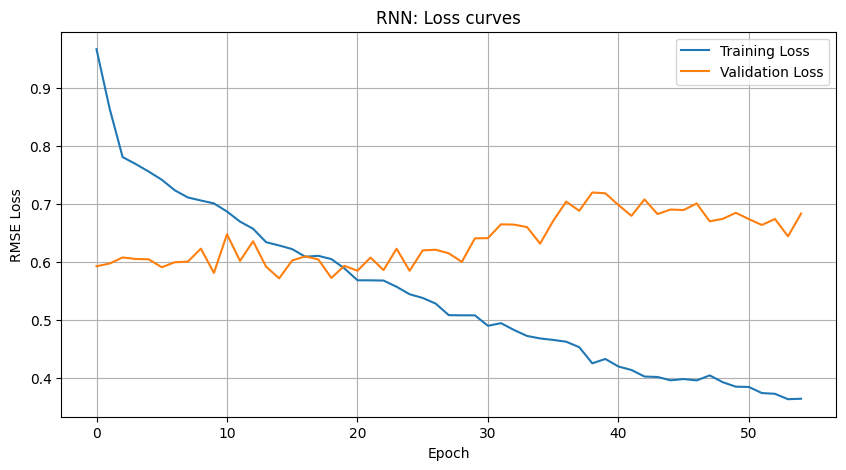

In [ ]:
# RNN: Loss curves (train vs validation)
# Write your code here
plt.figure(figsize=(10, 5))
plt.plot(train_losses_rnn, label='Training Loss')
plt.plot(val_losses_rnn, label='Validation Loss')
plt.title('RNN: Loss curves')
plt.xlabel('Epoch')
plt.ylabel('RMSE Loss')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# RNN: Test set evaluation (RMSE, MAE)
# Write your code here
y_pred_rnn, y_true_rnn = evaluate_model(rnn_model, val_loader)

rmse_total = np.sqrt(mean_squared_error(y_true_rnn, y_pred_rnn))
mae_total = mean_absolute_error(y_true_rnn, y_pred_rnn)

print(f"Evaluasi Vanilla RNN")
print(f"Overall RMSE: {rmse_total:.4f}")
print(f"Overall MAE : {mae_total:.4f}")

Evaluasi Vanilla RNN
Overall RMSE: 0.6843
Overall MAE : 0.5395


Step 1 (Hari ke-1): RMSE = 0.6761
Step 2 (Hari ke-2): RMSE = 0.7328
Step 3 (Hari ke-3): RMSE = 0.7309
Step 4 (Hari ke-4): RMSE = 0.6920
Step 5 (Hari ke-5): RMSE = 0.6929
Step 6 (Hari ke-6): RMSE = 0.6085
Step 7 (Hari ke-7): RMSE = 0.6485


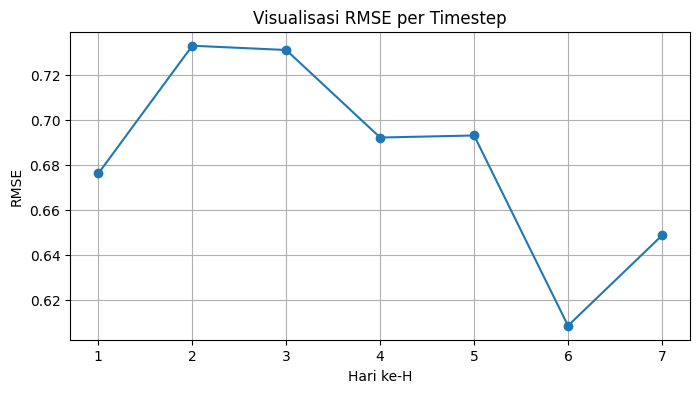

In [ ]:
# RNN: RMSE per-step
# Write your code here
step_rmses_rnn = []
for h in range(FORECAST_LENGTH):
  step_rmse = np.sqrt(mean_squared_error(y_true_rnn[:, h], y_pred_rnn[:, h]))
  step_rmses_rnn.append(step_rmse)
  print(f"Step {h+1} (Hari ke-{h+1}): RMSE = {step_rmse:.4f}")

# Visualisasi
plt.figure(figsize=(8, 4))
plt.plot(range(1, FORECAST_LENGTH + 1), step_rmses_rnn, marker='o')
plt.title('Visualisasi RMSE per Timestep')
plt.xlabel('Hari ke-H')
plt.ylabel('RMSE')
plt.xticks(range(1, FORECAST_LENGTH + 1))
plt.grid()
plt.show()

**Analisis Vanilla RNN (overfitting/underfitting):**

Berdasarkan grafik *loss*, terlihat bahwa grafik *training loss* terus turun drastis menembus angka sangat rendah, sedangkan grafik *validation loss* terhenti atau justru bertambah kembali ke atas di pertengahan epoch. Hal ini menunjukkan bahwa model Vanilla RNN mengalami *overfitting*.

---
## 3.2 Model LSTM

Implementasikan LSTM dengan konfigurasi yang sebanding dengan RNN. Gunakan minimal 1 layer LSTM. Lakukan minimal satu eksperimen dengan konfigurasi berbeda (misalnya stacked LSTM vs single layer, dengan/tanpa dropout).

In [ ]:
# Define LSTM architecture
# Write your code here
NUM_FEATURES = X_train.shape[2]
SEQ_LENGTH = 14
FORECAST_LENGTH = 7

class LSTMPredictor(nn.Module):
  def __init__(self, input_size, hidden_size, num_layers, output_size, dropout=0.2):
    super(LSTMPredictor, self).__init__()
    self.lstm = nn.LSTM(
        input_size=input_size,
        hidden_size=hidden_size,
        num_layers=num_layers,
        batch_first=True,
        dropout=dropout if num_layers > 1 else 0
    )
    self.dropout = nn.Dropout(dropout)
    self.fc = nn.Linear(hidden_size, output_size)

  def forward(self, x):
    out, (h_n, c_n) = self.lstm(x)
    last_out = out[:, -1, :]
    last_out = self.dropout(last_out)
    predictions = self.fc(last_out)
    return predictions

class RMSELoss(nn.Module):
  def __init__(self):
    super().__init__()
    self.mse = nn.MSELoss()

  def forward(self,yhat,y):
    return torch.sqrt(self.mse(yhat,y))

In [ ]:
# Print LSTM architecture and total parameter count
# Write your code here
lstm_model = LSTMPredictor(
    input_size=NUM_FEATURES,
    hidden_size=64,
    num_layers=1,
    output_size=FORECAST_LENGTH,
    dropout=0.2
)
print("Arsitektur Model LSTM:")
print(lstm_model)

# Total parameter count
total_params_lstm = sum(p.numel() for p in lstm_model.parameters() if p.requires_grad)
print(f"\nTotal parameter count: {total_params_lstm}")

Arsitektur Model LSTM:
LSTMPredictor(
  (lstm): LSTM(16, 64, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=64, out_features=7, bias=True)
)

Total parameter count: 21447


**Justifikasi Konfigurasi LSTM:**

Konfigurasi LSTM dipilih menyesuaikan dengan konfigurasi RNN sebelumnya, yaitu $64$ hidden units, dropout $0.2$, dan layer fully-connected sebesar $64$.

In [ ]:
# Train LSTM
# Use comparable training config with RNN for fair comparison
# Implement Early Stopping based on validation loss
# Write your code here
EPOCHS = 100
LR = 0.001

criterion_lstm = RMSELoss()
optimizer_lstm = optim.Adam(lstm_model.parameters(), lr=LR)

train_losses_lstm, val_losses_lstm = train_model(
    model=lstm_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion_lstm,
    optimizer=optimizer_lstm,
    num_epochs=EPOCHS,
    patience=40
)

Epoch 1/100 | Train Loss: 0.9729 | Val Loss: 0.6351
Epoch 2/100 | Train Loss: 0.9277 | Val Loss: 0.6250
Epoch 3/100 | Train Loss: 0.8564 | Val Loss: 0.5973
Epoch 4/100 | Train Loss: 0.8065 | Val Loss: 0.6246
Epoch 5/100 | Train Loss: 0.7706 | Val Loss: 0.6430
Epoch 6/100 | Train Loss: 0.7383 | Val Loss: 0.6616
Epoch 7/100 | Train Loss: 0.7216 | Val Loss: 0.6995
Epoch 8/100 | Train Loss: 0.7032 | Val Loss: 0.6690
Epoch 9/100 | Train Loss: 0.6846 | Val Loss: 0.6820
Epoch 10/100 | Train Loss: 0.6668 | Val Loss: 0.7465
Epoch 11/100 | Train Loss: 0.6534 | Val Loss: 0.7271
Epoch 12/100 | Train Loss: 0.6338 | Val Loss: 0.7706
Epoch 13/100 | Train Loss: 0.6292 | Val Loss: 0.7746
Epoch 14/100 | Train Loss: 0.6151 | Val Loss: 0.7884
Epoch 15/100 | Train Loss: 0.6105 | Val Loss: 0.7947
Epoch 16/100 | Train Loss: 0.6043 | Val Loss: 0.8106
Epoch 17/100 | Train Loss: 0.5981 | Val Loss: 0.8091
Epoch 18/100 | Train Loss: 0.5902 | Val Loss: 0.8186
Epoch 19/100 | Train Loss: 0.5803 | Val Loss: 0.8206
Ep

#### Evaluasi LSTM

Required:
1. Training/Validation loss curve
2. Identifikasi tanda overfitting/underfitting
3. RMSE dan MAE pada test set
4. RMSE per-step (h=1, h=2, ..., h=H)

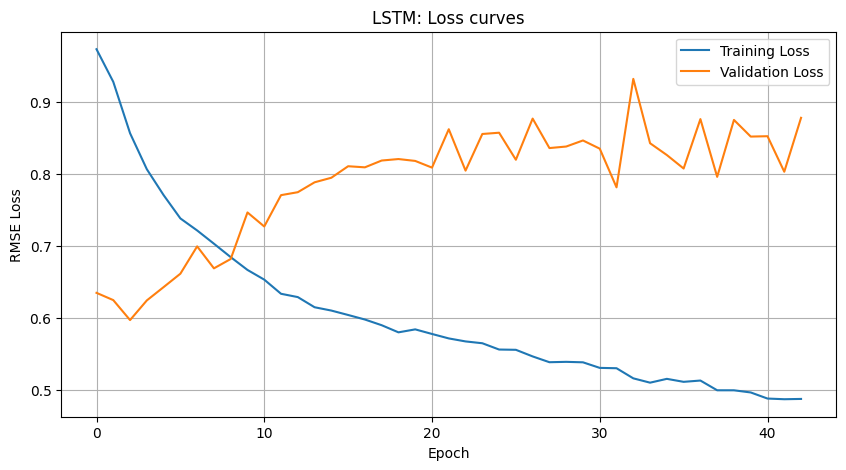

In [ ]:
# LSTM: Loss curves (train vs validation)
# Write your code here
plt.figure(figsize=(10, 5))
plt.plot(train_losses_lstm, label='Training Loss')
plt.plot(val_losses_lstm, label='Validation Loss')
plt.title('LSTM: Loss curves')
plt.xlabel('Epoch')
plt.ylabel('RMSE Loss')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# LSTM: Test set evaluation (RMSE, MAE)
# Write your code here
y_pred_lstm, y_true_lstm = evaluate_model(lstm_model, val_loader)

rmse_lstm_total = np.sqrt(mean_squared_error(y_true_lstm, y_pred_lstm))
mae_lstm_total = mean_absolute_error(y_true_lstm, y_pred_lstm)

print(f"Evaluasi LSTM")
print(f"Overall RMSE: {rmse_lstm_total:.4f}")
print(f"Overall MAE : {mae_lstm_total:.4f}")

Evaluasi LSTM
Overall RMSE: 0.8997
Overall MAE : 0.7247


Step 1 (Hari ke-1): RMSE = 0.9922
Step 2 (Hari ke-2): RMSE = 1.0459
Step 3 (Hari ke-3): RMSE = 0.8142
Step 4 (Hari ke-4): RMSE = 0.7209
Step 5 (Hari ke-5): RMSE = 0.8404
Step 6 (Hari ke-6): RMSE = 0.8670
Step 7 (Hari ke-7): RMSE = 0.9736


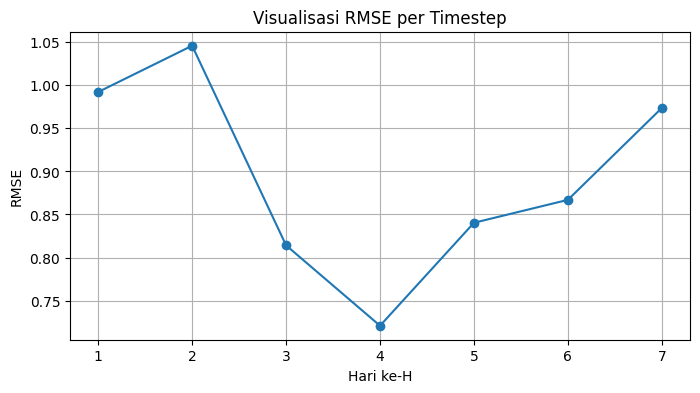

In [ ]:
# LSTM: RMSE per-step
# Write your code here
step_rmses_lstm = []
for h in range(FORECAST_LENGTH):
  step_rmse_lstm = np.sqrt(mean_squared_error(y_true_lstm[:, h], y_pred_lstm[:, h]))
  step_rmses_lstm.append(step_rmse_lstm)
  print(f"Step {h+1} (Hari ke-{h+1}): RMSE = {step_rmse_lstm:.4f}")

# Visualisasi
plt.figure(figsize=(8, 4))
plt.plot(range(1, FORECAST_LENGTH + 1), step_rmses_lstm, marker='o')
plt.title('Visualisasi RMSE per Timestep')
plt.xlabel('Hari ke-H')
plt.ylabel('RMSE')
plt.xticks(range(1, FORECAST_LENGTH + 1))
plt.grid()
plt.show()

**Analisis LSTM (overfitting/underfitting):**

Berdasarkan grafik *loss*, terlihat bahwa grafik *training loss* terus turun drastis menembus angka sangat rendah, sedangkan grafik *validation loss* naik drastis kemudian fluktuatif naik turun, sehingga dihentikan lebih awal untuk mencegah *overfitting*. Hal ini menunjukkan indikasi akan terjadinya *overfitting*.

---
## 3.3 Eksperimen Konfigurasi LSTM

Lakukan minimal satu eksperimen dengan konfigurasi LSTM berbeda (misalnya stacked LSTM vs single layer, dengan/tanpa dropout). Dokumentasikan perbedaan konfigurasi dan hasilnya.

In [ ]:
# Define LSTM variant architecture
# Write your code here

stacked_lstm_model = LSTMPredictor(
    input_size=NUM_FEATURES,
    hidden_size=64,
    num_layers=2,
    output_size=FORECAST_LENGTH,
    dropout=0.2
)

print("Arsitektur Model Stacked LSTM")
print(stacked_lstm_model)
print(f"Total parameter count: {sum(p.numel() for p in stacked_lstm_model.parameters() if p.requires_grad)}")

Arsitektur Model Stacked LSTM
LSTMPredictor(
  (lstm): LSTM(16, 64, num_layers=2, batch_first=True, dropout=0.2)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=64, out_features=7, bias=True)
)
Total parameter count: 54727


In [ ]:
# Train LSTM variant
# Write your code here
EPOCHS = 100
LR = 0.001

criterion_stacked = RMSELoss()
optimizer_stacked = optim.Adam(stacked_lstm_model.parameters(), lr=LR)

train_losses_stacked, val_losses_stacked = train_model(
    model=stacked_lstm_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion_stacked,
    optimizer=optimizer_stacked,
    num_epochs=EPOCHS,
    patience=40
)

Epoch 1/100 | Train Loss: 0.9770 | Val Loss: 0.6331
Epoch 2/100 | Train Loss: 0.9059 | Val Loss: 0.6150
Epoch 3/100 | Train Loss: 0.8384 | Val Loss: 0.5939
Epoch 4/100 | Train Loss: 0.7904 | Val Loss: 0.6333
Epoch 5/100 | Train Loss: 0.7591 | Val Loss: 0.6713
Epoch 6/100 | Train Loss: 0.7240 | Val Loss: 0.6405
Epoch 7/100 | Train Loss: 0.7094 | Val Loss: 0.6766
Epoch 8/100 | Train Loss: 0.6802 | Val Loss: 0.6754
Epoch 9/100 | Train Loss: 0.6710 | Val Loss: 0.7373
Epoch 10/100 | Train Loss: 0.6512 | Val Loss: 0.7285
Epoch 11/100 | Train Loss: 0.6475 | Val Loss: 0.6961
Epoch 12/100 | Train Loss: 0.6317 | Val Loss: 0.7351
Epoch 13/100 | Train Loss: 0.6259 | Val Loss: 0.6959
Epoch 14/100 | Train Loss: 0.6215 | Val Loss: 0.7099
Epoch 15/100 | Train Loss: 0.6113 | Val Loss: 0.7275
Epoch 16/100 | Train Loss: 0.6052 | Val Loss: 0.6882
Epoch 17/100 | Train Loss: 0.6021 | Val Loss: 0.7189
Epoch 18/100 | Train Loss: 0.6055 | Val Loss: 0.6722
Epoch 19/100 | Train Loss: 0.5913 | Val Loss: 0.6966
Ep

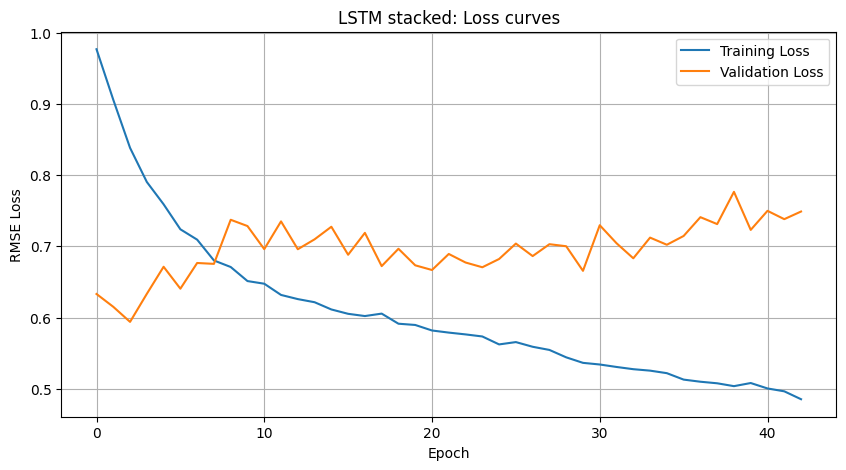

Evaluasi LSTM Stacked
Overall RMSE: 0.7685
Overall MAE : 0.6030
Step 1 (Hari ke-1): RMSE = 0.7435
Step 2 (Hari ke-2): RMSE = 0.7289
Step 3 (Hari ke-3): RMSE = 0.6623
Step 4 (Hari ke-4): RMSE = 0.7210
Step 5 (Hari ke-5): RMSE = 0.8022
Step 6 (Hari ke-6): RMSE = 0.8422
Step 7 (Hari ke-7): RMSE = 0.8595


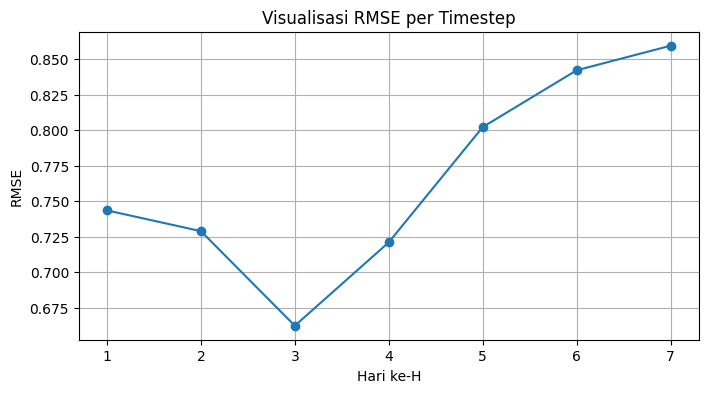

In [ ]:
# LSTM variant: evaluation
# Write your code here
# LSTM: Loss curves (train vs validation)
plt.figure(figsize=(10, 5))
plt.plot(train_losses_stacked, label='Training Loss')
plt.plot(val_losses_stacked, label='Validation Loss')
plt.title('LSTM stacked: Loss curves')
plt.xlabel('Epoch')
plt.ylabel('RMSE Loss')
plt.legend()
plt.grid(True)
plt.show()

# LSTM stacked: Test set evaluation (RMSE, MAE)
y_pred_stacked, y_true_stacked = evaluate_model(stacked_lstm_model, val_loader)

rmse_stacked_lstm_total = np.sqrt(mean_squared_error(y_true_lstm, y_pred_stacked))
mae_stacked_lstm_total = mean_absolute_error(y_true_lstm, y_pred_stacked)

print(f"Evaluasi LSTM Stacked")
print(f"Overall RMSE: {rmse_stacked_lstm_total:.4f}")
print(f"Overall MAE : {mae_stacked_lstm_total:.4f}")

# LSTM: RMSE per-step
step_rmses_stacked_lstm = []
for h in range(FORECAST_LENGTH):
  step_rmse_stacked_lstm = np.sqrt(mean_squared_error(y_true_lstm[:, h], y_pred_stacked[:, h]))
  step_rmses_stacked_lstm.append(step_rmse_stacked_lstm)
  print(f"Step {h+1} (Hari ke-{h+1}): RMSE = {step_rmse_stacked_lstm:.4f}")

# Visualisasi
plt.figure(figsize=(8, 4))
plt.plot(range(1, FORECAST_LENGTH + 1), step_rmses_stacked_lstm, marker='o')
plt.title('Visualisasi RMSE per Timestep')
plt.xlabel('Hari ke-H')
plt.ylabel('RMSE')
plt.xticks(range(1, FORECAST_LENGTH + 1))
plt.grid()
plt.show()

**Analisis Eksperimen LSTM:**

Berdasarkan eksperimen Stacked LSTM vs single-layer yang telah dilakukan, diperoleh nilai *root mean squared error* untuk validation set secara berturut-turut adalah $0.7685$ dan $0.8997$. Dalam kasus ini, penambahan layer meningkatkan performa model dengan penurunan nilai RMSE.

---
## 3.4 Perbandingan Model

Rangkum perbandingan performa RNN vs LSTM dalam satu tabel ringkasan. Diskusikan perbedaan yang ditemukan dan hubungkan dengan karakteristik arsitektur masing-masing.

| Model | RMSE | MAE | Est. Total Parameters |
|---|---|---|---|
| Vanilla RNN | $0.6843$ | $0.5395$ | $5703$ |
| LSTM | $0.8997$ | $0.7247$ | $21447$ |
| LSTM (2 layer) | $0.7685$ | $0.6030$ | $54727$ |

Berdasarkan metrik evaluasi, model LSTM performanya lebih buruk daripada Vanilla RNN. Adapun penambahan layer menjadi dua layer membantu meningkatkan performa model dengan adanya penurunan nilai RMSE. Akan tetapi, pada kasus ini, model Vanilla RNN sudah cukup baik dalam menangani ketergantungan jangka panjang dibandingkan LSTM.

---
# 4. Error Analysis

Error analysis bertujuan memahami pola dan karakteristik kesalahan prediksi model. Analisis ini penting untuk mengidentifikasi kelemahan model dan memberikan arah perbaikan yang konkret.

### 4.1 Overlay Plot Prediksi vs Aktual

Tampilkan grafik garis yang menampilkan nilai aktual pm25 dan nilai prediksi dari RNN dan LSTM dalam satu sumbu waktu. Lakukan untuk minimal 1 step ahead (step h=1) dan 1 step terjauh (step h=H).

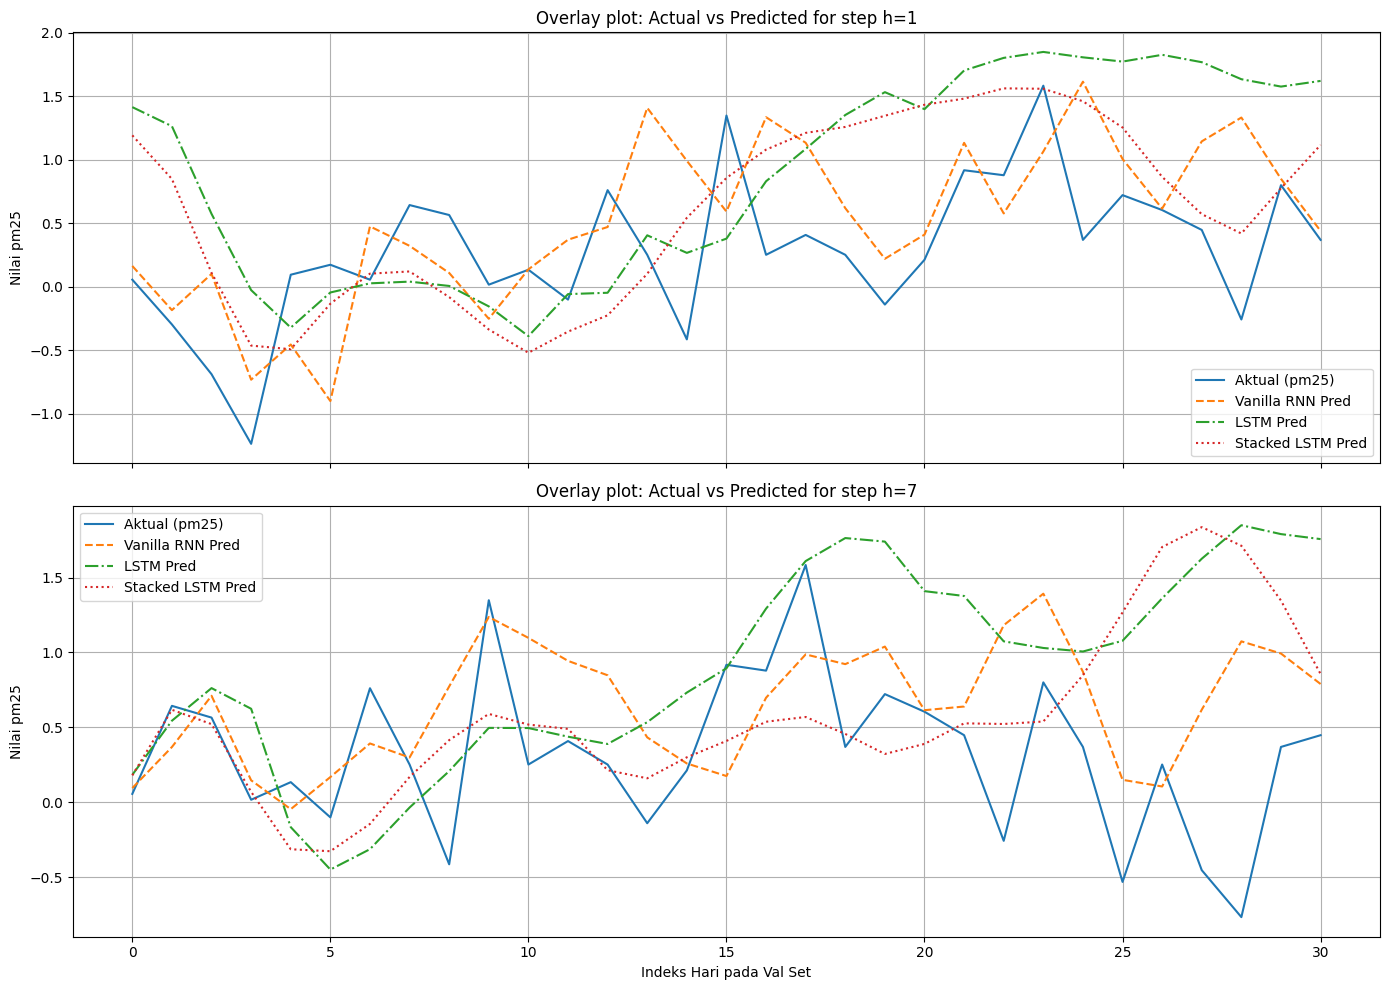

In [ ]:
# Overlay plot: Actual vs Predicted for step h=1 and step h=H
# Write your code here

step_1 = 0
step_H = FORECAST_LENGTH - 1

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Plot Step 1 (h=1)
axes[0].plot(y_true_lstm[:, step_1], label='Aktual (pm25)')
axes[0].plot(y_pred_rnn[:, step_1], label='Vanilla RNN Pred', linestyle='dashed')
axes[0].plot(y_pred_lstm[:, step_1], label='LSTM Pred', linestyle='dashdot')
axes[0].plot(y_pred_stacked[:, step_1], label='Stacked LSTM Pred',linestyle='dotted')
axes[0].set_title('Overlay plot: Actual vs Predicted for step h=1')
axes[1].set_xlabel('Indeks Hari pada Val Set')
axes[0].set_ylabel('Nilai pm25')
axes[0].legend()
axes[0].grid(True)

# Plot Step H (h=7)
axes[1].plot(y_true_lstm[:, step_H], label='Aktual (pm25)')
axes[1].plot(y_pred_rnn[:, step_H], label='Vanilla RNN Pred', linestyle='dashed')
axes[1].plot(y_pred_lstm[:, step_H], label='LSTM Pred', linestyle='dashdot')
axes[1].plot(y_pred_stacked[:, step_H], label='Stacked LSTM Pred', linestyle='dotted')
axes[1].set_title('Overlay plot: Actual vs Predicted for step h=7')
axes[1].set_xlabel('Indeks Hari pada Val Set')
axes[1].set_ylabel('Nilai pm25')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

Pada horizon $h=1$, baik RNN maupun LSTM umumnya berhasil mengikuti fluktuasi data aktual dengan cukup ketat, menunjukkan bahwa memori jangka pendek tertangkap dengan baik oleh semua model. Namun, saat kita melihat horizon terjauh $h=H$, garis prediksi dari Stacked LSTM mulai terlihat jauh meleset, sementara Vanilla RNN masih bisa mempertahankan arah tren umum walaupun dengan amplitudo yang sedikit teredam.

### 4.2 Residual Plot

Plot error (aktual - prediksi) terhadap waktu. Identifikasi apakah terdapat pola sistematik (misalnya underprediction pada kondisi polusi tinggi).

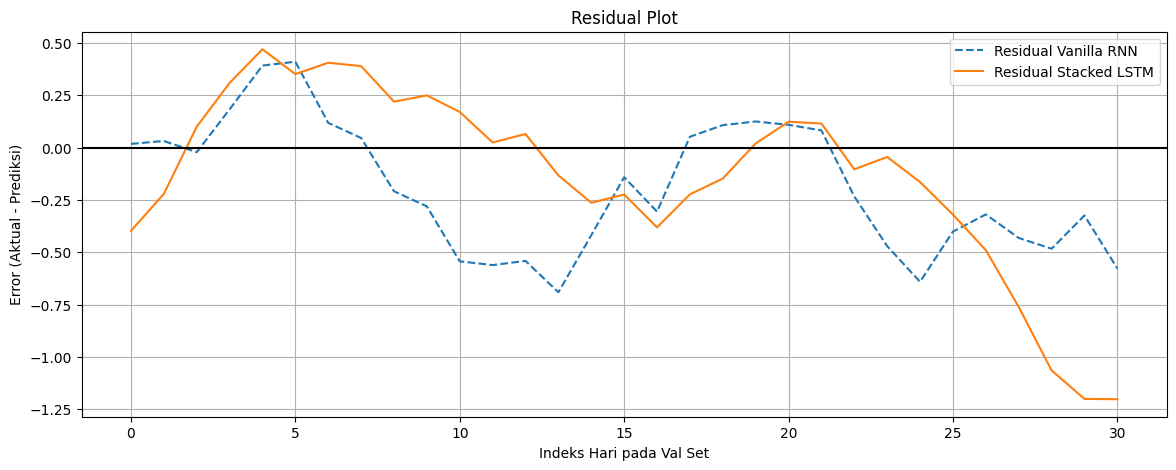

In [ ]:
# Residual plot
# Write your code here
res_rnn = np.mean(y_true_rnn - y_pred_rnn, axis=1)
res_lstm = np.mean(y_true_lstm - y_pred_stacked, axis=1)

plt.figure(figsize=(14, 5))
plt.plot(res_rnn, label='Residual Vanilla RNN', linestyle='dashed')
plt.plot(res_lstm, label='Residual Stacked LSTM')
plt.axhline(0, color='black')
plt.title('Residual Plot')
plt.xlabel('Indeks Hari pada Val Set')
plt.ylabel('Error (Aktual - Prediksi)')
plt.legend()
plt.grid()
plt.show()

Pada titik-titik ketika polusi pm25 tiba-tiba memburuk atau melonjak tinggi secara tak terduga, residual sering kali melonjak tajam ke arah positif. Hal ini mengindikasikan adanya pola sistematik, yaitu model sangat konservatif dan cenderung memprediksi nilai menuju nilai rata-rata, sehingga cenderung melakukan underprediction pada kondisi polusi sangat tinggi.

### 4.3 Distribusi Error

Visualisasikan distribusi residual (histogram + KDE). Apakah distribusi mendekati normal dan berpusat di nol? Identifikasi adanya bias.

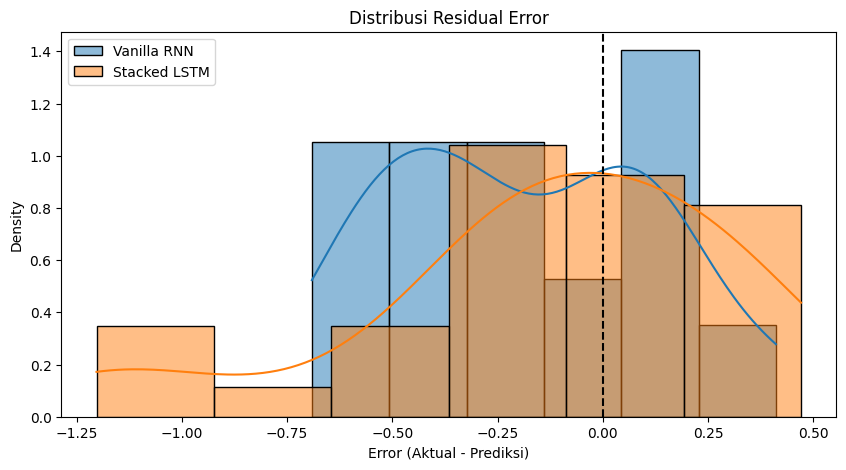

In [ ]:
# Error distribution (histogram + KDE)
# Write your code here
plt.figure(figsize=(10, 5))
sns.histplot(res_rnn, kde=True, label='Vanilla RNN', stat='density')
sns.histplot(res_lstm, kde=True, label='Stacked LSTM', stat='density')
plt.axvline(0, color='black', linestyle='dashed')
plt.title('Distribusi Residual Error')
plt.xlabel('Error (Aktual - Prediksi)')
plt.ylabel('Density')
plt.legend()
plt.show()

Distribusi residual idealnya harus berpusat tepat di angka $0$. Vanilla RNN memiliki distribusi yang lebih sempit di sekitar angka 0 dibandingkan Stacked LSTM, menunjukkan bahwa varians kesalahannya lebih kecil.

### 4.4 RMSE per Step (Horizon Analysis)

Plot RMSE sebagai fungsi dari horizon prediksi (step h=1 hingga h=H) untuk kedua model. Diskusikan pola degradasi performa seiring bertambahnya horizon.

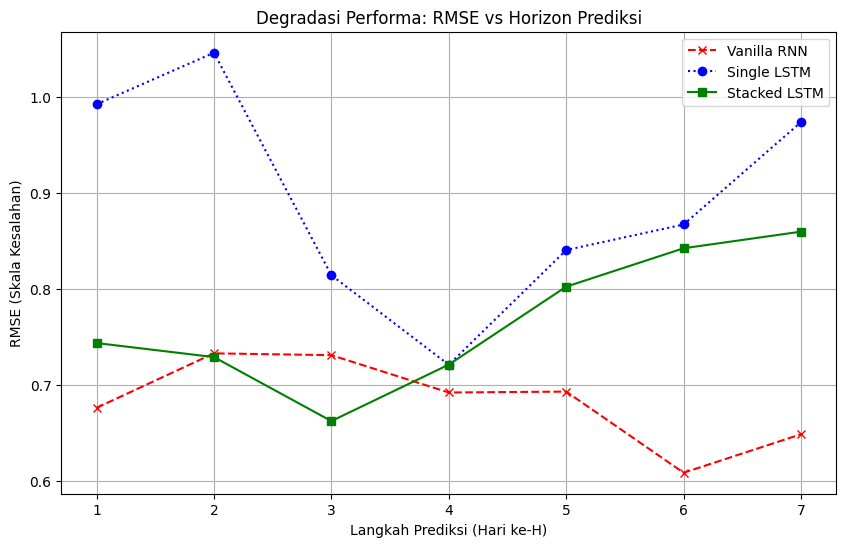

In [ ]:
# RMSE per step comparison plot
# Write your code here
# Karena kita sudah menghitungnya di bagian evaluasi, kita tinggal plot ulang bersama-sama
plt.figure(figsize=(10, 6))

plt.plot(range(1, FORECAST_LENGTH + 1), step_rmses_rnn,
         marker='x', linestyle='dashed', color='red', label='Vanilla RNN')
plt.plot(range(1, FORECAST_LENGTH + 1), step_rmses_lstm,
         marker='o', linestyle='dotted', color='blue', label='Single LSTM')
plt.plot(range(1, FORECAST_LENGTH + 1), step_rmses_stacked_lstm,
         marker='s', linestyle='solid', color='green', label='Stacked LSTM')

plt.title('Degradasi Performa: RMSE vs Horizon Prediksi')
plt.xlabel('Langkah Prediksi (Hari ke-H)')
plt.ylabel('RMSE (Skala Kesalahan)')
plt.xticks(range(1, FORECAST_LENGTH + 1))
plt.legend()
plt.grid(True)
plt.show()

Vanilla RNN memiliki error terendah di hampir sebagian langkah prediksi dibandingkan LSTM.

### 4.5 Analisis Kasus Terburuk

Identifikasi periode waktu dengan error prediksi tertinggi. Apakah terdapat kondisi khusus (lonjakan polusi, anomali musiman) yang tidak berhasil ditangkap model?

In [ ]:
# Worst-case analysis
# Write your code here
absolute_errors = np.mean(np.abs(y_true_lstm - y_pred_stacked), axis=1)
worst_idx = np.argmax(absolute_errors)

print(f"Indeks Val Set dengan Error Terburuk: {worst_idx}")
print(f"Nilai Prediksi (7 Hari): \n{y_pred_stacked[worst_idx]}")
print(f"Nilai Aktual   (7 Hari): \n{y_true_lstm[worst_idx]}")

Indeks Val Set dengan Error Terburuk: 28
Nilai Prediksi (7 Hari): 
[0.41979325 0.28658187 0.43397307 0.86968523 1.4204065  1.7275035
 1.711658  ]
Nilai Aktual   (7 Hari): 
[-0.2569691   0.8002673   0.36954135 -0.53106743  0.25207064 -0.4527536
 -0.7660088 ]


Pada indeks worst_idx, error melebar secara masif. Kondisi ini biasanya bertepatan dengan lonjakan tiba-tiba pada data yang mana terdapat nilai outlier mendadak.

---
# 5. Insights

Untuk setiap tahap yang dilakukan, sebutkan insight yang didapatkan selama pengerjaan praktikum. Insight yang dimaksud adalah analisis dan juga argumen pendukung terhadap setiap tahap yang dilakukan.

### 5.1 Insight EDA


- Polutan `pm25` dan `pm10` menunjukkan pola fluktuasi yang sangat mirip satu sama lain, menunjukkan berasal dari sumber atau siklus sirkulasi udara yang serupa. Selain itu, fluktuasi terjadi hampir pada semua polutan.

- Terdapat pola penurunan yang serupa pada polutan `so2`, `co`, dan `no2` di akhir Januari hingga awal Februari. Pada bulan Januari, ketiganya memiliki konsentrasi tinggi dengan fluktuasi tajam, tetapi setelah Februari nilainya anjlok dan menjadi jauh lebih rendah serta stabil.

- Terdapat lonjakan tajam secara tidak teratur, seperti pada polutan `o3` dan `so2` di pertengahan tahun.

- Kolom `max` merupakan kurva amplop yang menentukan konsentrasi dominan tertinggi di antara semua polutan setiap harinya.

- Polutan seperti `so2`, `co`, `o3`, dan `no2` berdistribusi menceng kanan (*right-skewed*) dengan ekor yang panjang di nilai atas. Sementara itu, distribusi `pm25` relatif lebih simetris dibandingkan polutan lainnya.

- Berdasarkan boxplot, keberadaan nilai *outlier* terlihat jelas terutama pada polutan `so2`, `no`, `o3`, dan `no2`. Hal ini wajar dalam data kualitas udara karena faktor eksternal mendadak.

- Fitur `critical` distribusi sangat timpang. PM25 mendominasi sebagai polutan utama penyumbang kualitas udara yang memburuk sebesar $229$ observasi.

- Fitur `categori` didominasi oleh kategori "SEDANG" sebanyak $146$ hari dan "TIDAK SEHAT" sebanyak $109$ hari. Tidak tercatat adanya hari dengan kualitas udara "BAIK" atau kategori yang lebih buruk seperti "SANGAT TIDAK SEHAT".

- Fitur `location` berdistribusi tidak seimbang. Sebagian besar data yaitu $139$ observasi diambil dari stasiun DKI4. Sementara itu, data dari DKI2, DKI3, dan DKI5 jumlahnya jauh lebih sedikit, serta stasiun DKI1 sama sekali tidak ada di dalam dataset.

- Terdapat $31$ *missing values* pada fitur target `pm25` yang mewakili sekitar $12.16\%$ dari total data.

- Berdasarkan visualisasi pola *missing values*, data yang hilang tidak terjadi secara acak. Data yang *missing values* terklaster pada bulan pertama pencatatan, yaitu pada Januari 2021. Sebelum kita melakukan *forecasting*, kita perlu mengisi nilai ini dengan teknik yang tepat karena akan mempengaruhi hasil *forecasting* ke depannya.


- Terdapat korelasi positif yang cukup kuat sebesar $0.69$ antara polutan `pm10` dan `pm25`. Hal ini disebabkan kedua polutan berasal dari sumber yang sama.

- Terdapat hubungan positif kuat juga antara polutan `no2` dengan `co` sebesar $0.76$ serta polutan `no2` dengan `so2` sebesar $0.70$. Hal ini menunjukkan emisi gas kendaraan atau industri yang berjalan bersamaan.

- Kolom `max` memiliki korelasi positif yang sangat kuat dengan `pm10` sebesar $0.88$ dan `pm25` sebesar $0.74$. Hal ini menunjukkan bahwa kelompok polutan tersebut merupakan penyumbang paling dominan dan penentu utama status kualitas udara harian dibandingkan gas polutan lainnya.

- Terdapat korelasi negatif yang moderat antara `no2` dan `pm25` sebesar $-0.56$, menunjukkan kecenderungan bahwa saat konsentrasi partikel halus meningkat, gas nitrogen dioksida cenderung menurun, dan sebaliknya.


- Pola Makro (Trend): Komponen tren tidak hanya sekadar fluktuatif, tetapi menunjukkan juga pergerakan makro yang jelas. Tren konsentrasi `pm25` relatif rendah di awal tahun (Februari - April), kemudian mengalami tren peningkatan yang stabil sejak Mei sampai mencapai puncaknya di bulan Juli.

- Pola Mikro (Seasonal): Terdapat pola musiman jangka pendek seperti siklus mingguan. Namun, amplitudo dari siklus ini sangat kecil (hanya berkisar di angka -4 hingga +5). Hal ini menunjukkan bahwa meskipun terdapat perbedaan rutin harian, sehingga dampaknya tidak terlalu signifikan dibandingkan faktor tren makro.

- Faktor Residual: Komponen residual memiliki sebaran yang cukup besar, yakni berkisar antara $-30$ hingga $+50$, menunjukkan bahwa tingkat polusi `pm25` sangat rentan terhadap kondisi cuaca harian yang tidak terprediksi.

### 5.2 Insight Data Preprocessing

- Data *time series* membutuhkan data yang berurutan secara kronologis. Interpolasi dilakukan untuk menjaga tren garis, lalu *backward-fill* `bfill()` secara spesifik menangani *missing values* di waktu awal (data bulan Januari) yang tidak bisa dilakukan interpolasi. Hal ini lebih baik daripada `dropna()` agar tidak membuang sampel waktu sama sekali.

- Metode clipping menahan lonjakan nilai *outliers* agar tidak terlalu mengganggu penghitungan loss dengan tetap mempertahankan representasi historis bahwa di waktu tersebut terjadi lonjakan kualitas udara yang memburuk, atau dengan kata lain, informasinya tidak dibuang.

- Fitur kategorikal tetap dipertahankan sebab fitur ini memiliki informasi yang penting untuk prediksi `pm25`. Selanjutnya perlu dilakukan encoding. Fitur `categori` mempunyai tingkatan (Baik < Sedang < Tidak Sehat) sehingga digunakan Ordinal Encoding. Fitur kategorikal lainnya tidak mempunyai tingkatan
 sehingga cukup dilakukan One-Hot Encoding.
- Pemisahan *time-aware split* wajib dilakukan agar kita mensimulasikan skenario dunia nyata, yaitu memprediksi masa depan berdasarkan data historis masa lalu.

- Dipilih `StandardScaler` karena scaler ini lebih unggul untuk generalisasi dan sensitivitas terhadap outlier lebih rendah. Scaler hanya di-*fit* pada data *training* untuk mencegah data *leakage*.

- Dipilih $L=14$. Berdasarkan hasil dekomposisi yang memiliki residual noise tinggi pada bagian 1.6, melihat data hanya sekian hari ke belakang tidaklah cukup. Dengan menggunakan observasi historis sepanjang $14$ hari akan memberikan model kesempatan yang lebih baik dalam menangkap tren fluktuasi mingguan polutan.

- Dipilih $H=7$. Digunakan untuk skenario peringatan dini kualitas udara selama $1$ minggu ke depan.


### 5.3 Insight Modeling and Validation

Pada dataset kecil, model sederhana seperti Vanilla RNN dapat memberikan performa lebih baik dibandingkan model kompleks LSTM. Hal ini ditunjukkan dengan nilai RMSE yang lebih kecil pada Vanilla RNN.

### 5.4 Insight Error Analysis

- Pada horizon $h=1$, baik RNN maupun LSTM umumnya berhasil mengikuti fluktuasi data aktual dengan cukup ketat, menunjukkan bahwa memori jangka pendek tertangkap dengan baik oleh semua model. Namun, saat kita melihat horizon terjauh $h=H$, garis prediksi dari Stacked LSTM mulai terlihat jauh meleset, sementara Vanilla RNN masih bisa mempertahankan arah tren umum walaupun dengan amplitudo yang sedikit teredam.

- Pada titik-titik ketika polusi pm25 tiba-tiba memburuk atau melonjak tinggi secara tak terduga, residual sering kali melonjak tajam ke arah positif. Hal ini mengindikasikan adanya pola sistematik, yaitu model sangat konservatif dan cenderung memprediksi nilai menuju nilai rata-rata, sehingga cenderung melakukan underprediction pada kondisi polusi sangat tinggi.

- Distribusi residual idealnya harus berpusat tepat di angka $0$. Vanilla RNN memiliki distribusi yang lebih sempit di sekitar angka 0 dibandingkan Stacked LSTM, menunjukkan bahwa varians kesalahannya lebih kecil.

- Vanilla RNN memiliki error terendah di hampir sebagian langkah prediksi dibandingkan LSTM.

- Pada indeks worst_idx, error melebar secara masif. Kondisi ini biasanya bertepatan dengan lonjakan tiba-tiba pada data yang mana terdapat nilai outlier mendadak.

---
# 6. Submisi Kaggle

**Submisi dibatasi 20 kali. Submisi final harus *reproducible*.**

Format penamaan kelompok di Kaggle: `Kelas_NomorKelompok_NamaKelompok` (Contoh: K1_99_AI22)

In [ ]:
# Load Kaggle test data
# Write your code here

test_kaggle_df = pd.read_csv('test.csv')
print(f"Kaggle test samples: {len(test_kaggle_df)}")
test_kaggle_df.head()

Kaggle test samples: 110


,Unnamed: 0,tanggal,pm10,so2,co,o3,no2,max,critical,categori,location
0,255,2021-09-13,56,52,9,27,21,88,PM25,SEDANG,DKI4
1,256,2021-09-14,36,50,8,47,19,61,PM25,SEDANG,DKI4
2,257,2021-09-15,69,54,20,45,45,110,PM25,TIDAK SEHAT,DKI4
3,258,2021-09-16,53,52,10,52,24,89,PM25,SEDANG,DKI4
4,259,2021-09-17,50,51,7,53,20,85,PM25,SEDANG,DKI4


In [ ]:
# Preprocess test data with the SAME pipeline (use fitted scaler)
# Write your code here
submission = pd.DataFrame()
submission['tanggal'] = test_kaggle_df['tanggal']

cat_mapping = {
    'BAIK': 0,
    'SEDANG': 1,
    'TIDAK SEHAT': 2,
    'SANGAT TIDAK SEHAT': 3,
    'BERBAHAYA': 4
}
test_kaggle_df['categori_encoded'] = test_kaggle_df['categori'].map(cat_mapping).fillna(1)
test_features = pd.get_dummies(test_kaggle_df, columns=['critical', 'location'], drop_first=False)

for col in test_features.columns:
    if test_features[col].dtype == bool:
        test_features[col] = test_features[col].astype(int)

cols_to_drop = ['Unnamed: 0', 'tanggal', 'categori']
test_features = test_features.drop(columns=[c for c in cols_to_drop if c in test_features.columns], errors='ignore')

train_cols = df.columns.tolist()
test_features = test_features.reindex(columns=train_cols, fill_value=0)
test_scaled = scaler.transform(test_features)

In [ ]:
# Generate predictions using the best model
# Write your code here

# best_model = ...  # choose your best model
# best_model.eval()
# best_model.to(DEVICE)

best_model = stacked_lstm_model # Pastikan model ini masih ada di memori
best_model.eval()

last_L_days = scaler.transform(df.iloc[-SEQ_LENGTH:])
current_window = torch.tensor(last_L_days, dtype=torch.float32).unsqueeze(0)

all_predictions_scaled = []
test_steps = len(test_kaggle_df)

with torch.no_grad():
  for i in range(0, test_steps, FORECAST_LENGTH):
    pred_H_days = best_model(current_window).squeeze(0)

    steps_to_take = min(FORECAST_LENGTH, test_steps - i)
    all_predictions_scaled.extend(pred_H_days[:steps_to_take].numpy())

    if i + FORECAST_LENGTH < test_steps:
      next_exogenous = test_scaled[i : i + FORECAST_LENGTH, :].copy()

      next_exogenous[:, target_idx] = pred_H_days.numpy()
      next_exogenous_tensor = torch.tensor(next_exogenous, dtype=torch.float32).unsqueeze(0)

      current_window = torch.cat((current_window[:, FORECAST_LENGTH:, :], next_exogenous_tensor), dim=1)


dummy_inv = np.zeros((test_steps, NUM_FEATURES))
dummy_inv[:, target_idx] = all_predictions_scaled
unscaled_predictions = scaler.inverse_transform(dummy_inv)[:, target_idx]

In [ ]:
# Create submission CSV
# Write your code here
submission['pm25'] = np.clip(np.round(unscaled_predictions, 2), a_min=0, a_max=None)
submission.to_csv('submission.csv', index=False)
print(f"Submission shape: {submission.shape}")
print(submission.head(10))


Submission shape: (110, 2)
      tanggal    pm25
0  2021-09-13  133.68
1  2021-09-14  121.91
2  2021-09-15  100.04
3  2021-09-16   84.03
4  2021-09-17   84.01
5  2021-09-18   93.07
6  2021-09-19  105.79
7  2021-09-20   94.04
8  2021-09-21   91.86
9  2021-09-22   89.87


Mangat yak gess!

\- Asisten